In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pickle
import cv2
from lime import lime_image
from skimage.segmentation import mark_boundaries

# Import the model AND the preprocessing function
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input as model_preprocess
from tensorflow.keras import layers, models

In [2]:
# --- 1. Load the Test Data ---
print("Loading test data...")
X_test = np.load('../data/processed/X_test_hyper.npy')
y_test = np.load('../data/processed/y_test_hyper.npy')
with open('../models/hyper_label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

# --- 2. Pick One Image to Test ---
image_index = 5 # You can change this number
# LIME needs the image in (H, W, 3) format
sample_image = X_test[image_index] 
true_label_name = le.classes_[le.transform([y_test[image_index]])[0]]

print(f"Loaded sample image {image_index}. True label: {true_label_name}")
print(f"Image shape: {sample_image.shape}")

Loading test data...
Loaded sample image 5. True label: 0.5
Image shape: (128, 128, 3)


In [3]:
print("Building clean Functional model architecture...")

# 1. Define the base ResNet model
base_model = ResNet50(weights=None, include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False 

# 2. Build the full Functional model
inputs = layers.Input(shape=(128, 128, 3), name="clean_input")
x = layers.Rescaling(255.0)(inputs)
x = layers.Lambda(model_preprocess)(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(3, activation='softmax')(x) # 3 classes

# 3. Create the new, clean model
clean_model = models.Model(inputs, outputs, name="clean_functional_model")

# 4. Load the Saved Weights
print("Loading saved weights from '../models/nutrient_hyper_model.h5'...")
clean_model.load_weights('../models/nutrient_hyper_model.h5')

print("Model built and weights loaded successfully.")

Building clean Functional model architecture...

Loading saved weights from '../models/nutrient_hyper_model.h5'...
Model built and weights loaded successfully.


In [4]:
def lime_predict_fn(images):
    """
    This function takes the perturbed images from LIME
    and returns the model's predictions.
    """
    # LIME passes images as a batch, which is what our model expects
    return clean_model.predict(images)

# --- Test the function with our sample image ---
# LIME needs a batch, so we add a dimension
sample_image_batch = np.expand_dims(sample_image, axis=0)
preds = lime_predict_fn(sample_image_batch)

# Get prediction info
pred_class_index = np.argmax(preds[0])
pred_class_name = le.classes_[pred_class_index]
confidence = np.max(preds[0]) * 100

print(f"\nModel prediction: {pred_class_name} (Confidence: {confidence:.2f}%)")
print(f"True label: {true_label_name}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step

Model prediction: 1.0 (Confidence: 63.79%)
True label: 0.5


Starting LIME explanation... This will take a minute or two.


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

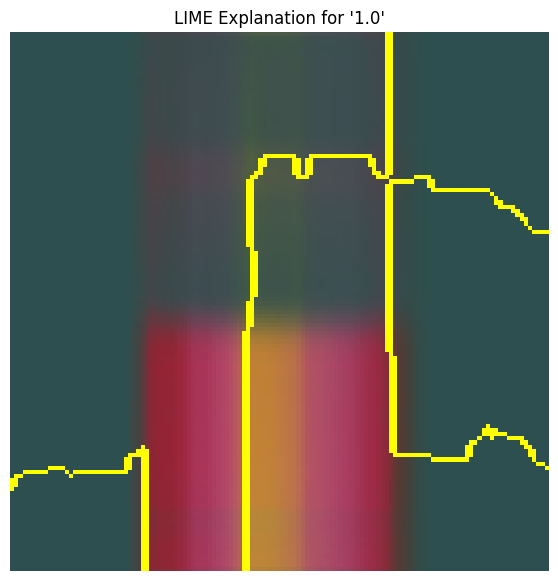

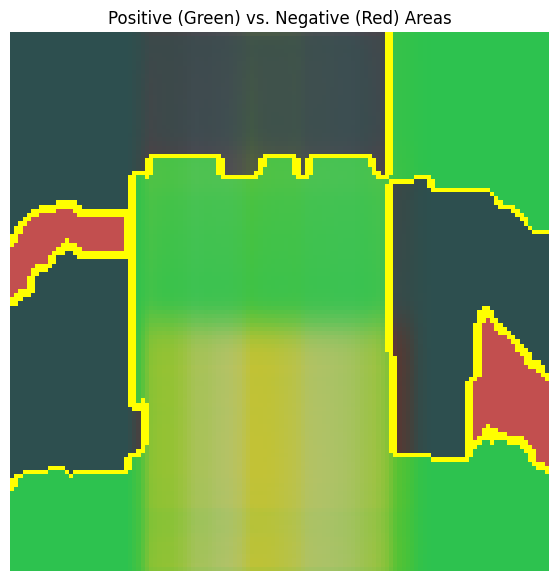

In [5]:
print("Starting LIME explanation... This will take a minute or two.")

# 1. Initialize the LIME Explainer
explainer = lime_image.LimeImageExplainer()

# 2. Get the explanation
#    - sample_image: The single image we want to explain
#    - lime_predict_fn: The "black box" prediction function we just made
#    - top_labels: How many classes to explain (we want all 3)
#    - num_samples: How many "tests" to run. 1000 is a good balance.
explanation = explainer.explain_instance(
    sample_image, 
    lime_predict_fn, 
    top_labels=3, 
    hide_color=0, 
    num_samples=1000
)

print("Explanation complete.")

# --- 3. Visualize the Results ---
print(f"Visualizing LIME for prediction: {pred_class_name} (True: {true_label_name})")

# Get the image and mask for the predicted class
# This mask shows the "superpixels" that LIME found most important
temp, mask = explanation.get_image_and_mask(
    pred_class_index, 
    positive_only=True, 
    num_features=5, # Show the top 5 most important areas
    hide_rest=False
)

# Plot the explanation
plt.figure(figsize=(7, 7))
plt.imshow(mark_boundaries(temp, mask))
plt.title(f"LIME Explanation for '{pred_class_name}'")
plt.axis('off')
plt.show()

# You can also see the areas that argue *against* the prediction:
temp, mask = explanation.get_image_and_mask(
    pred_class_index, 
    positive_only=False, # Show positive AND negative areas
    num_features=10, 
    hide_rest=False
)

plt.figure(figsize=(7, 7))
plt.imshow(mark_boundaries(temp, mask))
plt.title(f"Positive (Green) vs. Negative (Red) Areas")
plt.axis('off')
plt.show()